# Modern time-series forecasting

## From raw transactions to honest forecasts

This tutorial turns the **Predict Future Sales** transactions into a monthly time series and develops a forecasting workflow that is statistically sound, visually clear, and reproducible.

> **Polars-first workflow.** Polars handles loading, validation, aggregation, panel reshaping, and lag features. We convert a single aggregated series to pandas/NumPy only at the boundary where `statsmodels` requires those types.

### What you will learn

1. How transactional data becomes a regular time series.
2. How to distinguish trend, seasonality, cycles, and noise.
3. Why stationarity matters and how differencing changes a series.
4. How to read the ACF and PACF without treating them as magic order selectors.
5. How to evaluate forecasts without leaking future information.
6. How naive, drift, ETS, and SARIMA forecasts compare on real data.
7. How residual diagnostics and uncertainty affect a forecasting decision.

The dataset contains only **34 monthly observations**. That limitation is part of the lesson: complex models do not become trustworthy merely because they can be fitted.

## 0. Setup and reproducibility

The code uses current APIs from Polars and `statsmodels`; it avoids the removed `statsmodels.tsa.arima_model.ARMA` interface used by older tutorials.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning

RANDOM_SEED = 42
SEASON_LENGTH = 12
rng = np.random.default_rng(RANDOM_SEED)

COLORS = {
    "actual": "#173F5F",
    "trend": "#D1495B",
    "seasonal": "#00798C",
    "accent": "#EDA544",
    "test": "#F3E9D2",
    "grid": "#D9E2EC",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.titleweight": "bold",
        "axes.edgecolor": "#334E68",
        "grid.color": COLORS["grid"],
        "grid.alpha": 0.7,
        "legend.frameon": False,
    }
)

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(12)

pl.DataFrame(
    {
        "package": ["Python", "Polars", "pandas", "statsmodels"],
        "version": [
            sys.version.split()[0],
            pl.__version__,
            pd.__version__,
            sm.__version__,
        ],
    }
)

package,version
str,str
"""Python""","""3.11.15"""
"""Polars""","""1.43.2"""
"""pandas""","""3.0.3"""
"""statsmodels""","""0.14.6"""


## 1. Load and understand the transactions

Each row is a shop–item transaction aggregate for one day. The forecasting target used here is **net units sold per month across all shops and items**.

In [2]:
DATA_PATH = Path("data/sales_train.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH.resolve()}. Place the Predict Future Sales "
        "files in a data/ directory beside this notebook."
    )

sales = (
    pl.scan_csv(DATA_PATH)
    .with_columns(
        pl.col("date").str.strptime(pl.Date, format="%d.%m.%Y")
    )
    .collect()
)

sales.head()

date,date_block_num,shop_id,item_id,item_price,item_cnt_day
date,i64,i64,i64,f64,f64
2013-01-02,0,59,22154,999.0,1.0
2013-01-03,0,25,2552,899.0,1.0
2013-01-05,0,25,2552,899.0,-1.0
2013-01-06,0,25,2554,1709.05,1.0
2013-01-15,0,25,2555,1099.0,1.0


In [3]:
summary_values = sales.select(
    pl.len().alias("rows"),
    pl.col("date").min().alias("first_date"),
    pl.col("date").max().alias("last_date"),
    pl.col("date_block_num").n_unique().alias("months"),
    pl.col("shop_id").n_unique().alias("shops"),
    pl.col("item_id").n_unique().alias("items"),
    (pl.col("item_cnt_day") < 0).sum().alias("return_rows"),
    (pl.col("item_price") < 0).sum().alias("negative_price_rows"),
).row(0, named=True)

data_summary = pl.DataFrame(
    {
        "metric": list(summary_values),
        "value": [str(value) for value in summary_values.values()],
    }
)
data_summary

metric,value
str,str
"""rows""","""2935849"""
"""first_date""","""2013-01-01"""
"""last_date""","""2015-10-31"""
"""months""","""34"""
"""shops""","""60"""
"""items""","""21807"""
"""return_rows""","""7356"""
"""negative_price_rows""","""1"""


### Data decisions

- Negative quantities represent returns, so monthly sums are **net sales**, not gross sales.
- The single negative-price record does not affect this tutorial because price is not part of the target.
- Aggregation is a modeling choice: total sales are smooth enough to teach the concepts, while individual item–shop series are often sparse and intermittent.
- Time order is never shuffled.

## 2. Construct a regular monthly series

A time series needs an ordered time index and a fixed frequency. We truncate each date to its month and aggregate net units.

In [4]:
monthly_total = (
    sales.with_columns(pl.col("date").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg(pl.col("item_cnt_day").sum().alias("net_units"))
    .sort("month")
)

expected_months = pl.date_range(
    monthly_total["month"].min(),
    monthly_total["month"].max(),
    interval="1mo",
    eager=True,
)
assert monthly_total["month"].to_list() == expected_months.to_list()

# statsmodels boundary: only the final 34-point series becomes pandas.
y = pd.Series(
    monthly_total["net_units"].to_numpy(),
    index=pd.DatetimeIndex(monthly_total["month"].to_list()),
    name="net_units",
    dtype=float,
).asfreq("MS")

monthly_total

month,net_units
date,f64
2013-01-01,131479.0
2013-02-01,128090.0
2013-03-01,147142.0
2013-04-01,107190.0
2013-05-01,106970.0
2013-06-01,125381.0
…,…
2015-05-01,72295.0
2015-06-01,64114.0


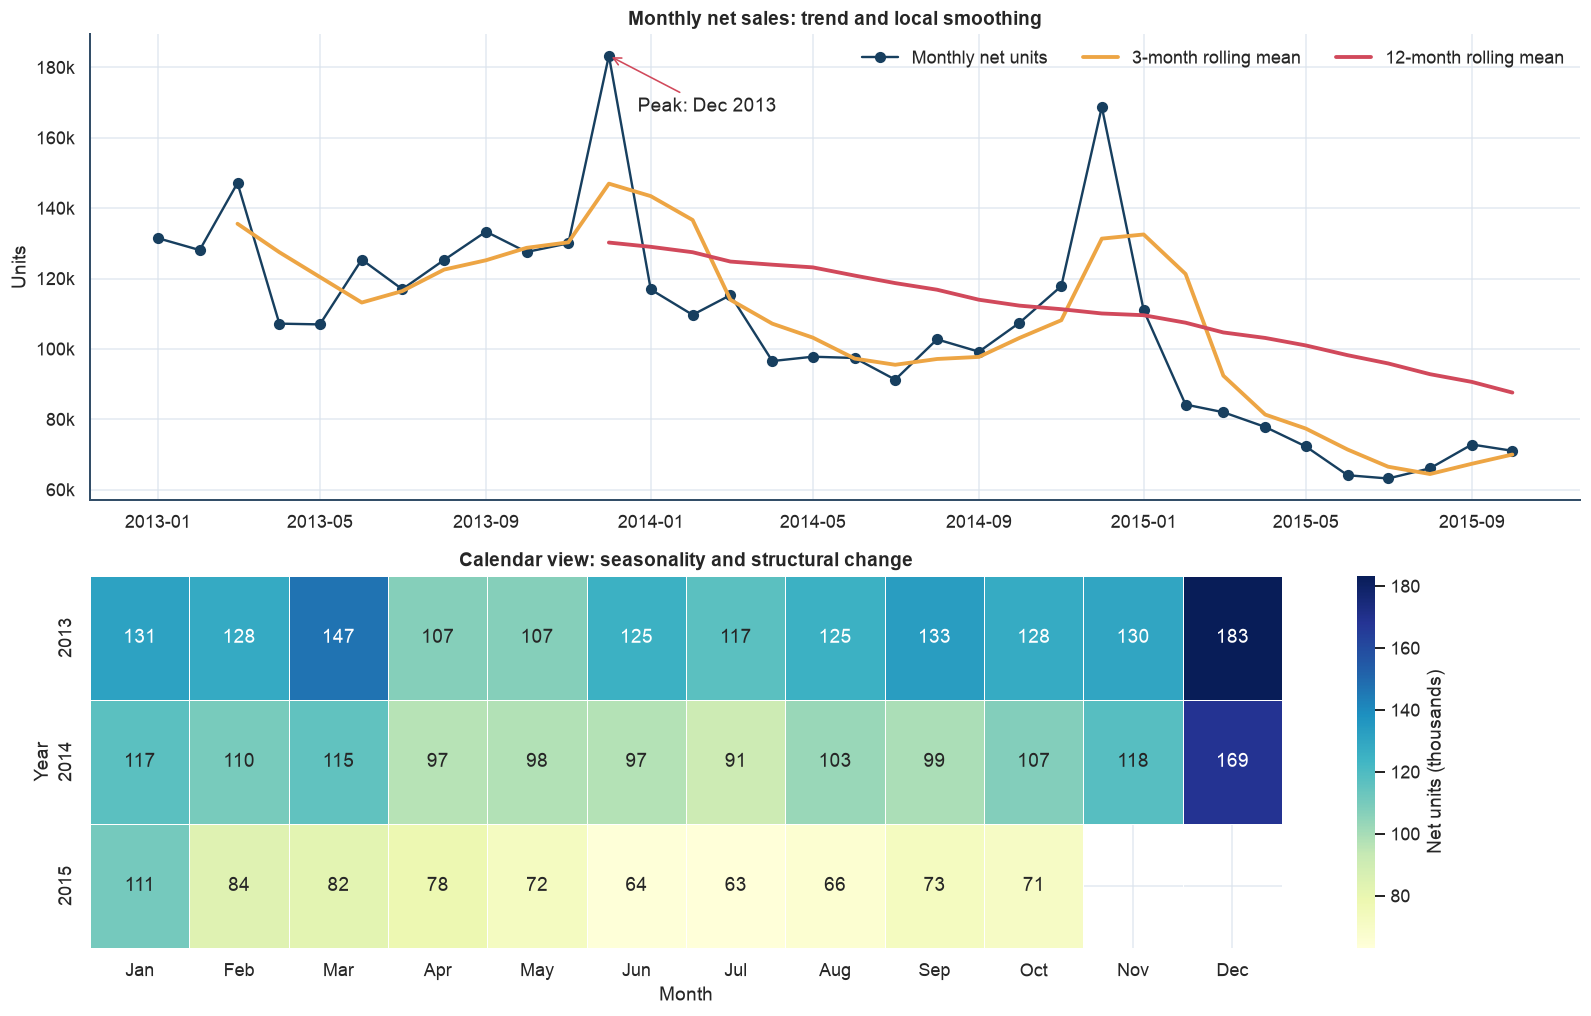

In [5]:
calendar = (
    monthly_total.with_columns(
        pl.col("month").dt.year().alias("year"),
        pl.col("month").dt.month().alias("month_number"),
    )
    .pivot(on="month_number", index="year", values="net_units")
    .sort("year")
)
month_columns = [str(month) for month in range(1, 13)]
calendar = calendar.select(["year", *month_columns])

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    gridspec_kw={"height_ratios": [1.25, 1]},
)

axes[0].plot(y.index, y, color=COLORS["actual"], marker="o", label="Monthly net units")
axes[0].plot(
    y.index,
    y.rolling(3).mean(),
    color=COLORS["accent"],
    linewidth=2.4,
    label="3-month rolling mean",
)
axes[0].plot(
    y.index,
    y.rolling(12).mean(),
    color=COLORS["trend"],
    linewidth=2.4,
    label="12-month rolling mean",
)
peak_month = y.idxmax()
axes[0].annotate(
    f"Peak: {peak_month:%b %Y}",
    xy=(peak_month, y.max()),
    xytext=(18, -35),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": COLORS["trend"]},
)
axes[0].set(title="Monthly net sales: trend and local smoothing", ylabel="Units")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))
axes[0].legend(ncol=3, loc="upper right")
sns.despine(ax=axes[0])

heat_values = calendar.select(month_columns).to_numpy().astype(float) / 1_000
sns.heatmap(
    heat_values,
    mask=np.isnan(heat_values),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.6,
    cbar_kws={"label": "Net units (thousands)"},
    xticklabels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    yticklabels=calendar["year"].to_list(),
    ax=axes[1],
)
axes[1].set(title="Calendar view: seasonality and structural change", xlabel="Month", ylabel="Year")

fig.tight_layout()
plt.show()

### First reading

- **Trend:** the overall sales level falls over the three years.
- **Seasonality:** November and especially December tend to be stronger.
- **Structural change:** the same calendar month is often lower in later years, so a pure seasonal-repeat forecast will be biased upward.
- **Noise:** month-to-month deviations remain after trend and seasonality.

A rolling mean is a visual smoother, not yet a forecasting model.

## 3. Decompose the observed series

An additive decomposition writes

$$
y_t = T_t + S_t + R_t,
$$

where $T_t$ is trend, $S_t$ is a repeating seasonal component, and $R_t$ is the remainder. STL uses locally weighted regressions and can be made robust to unusual observations.

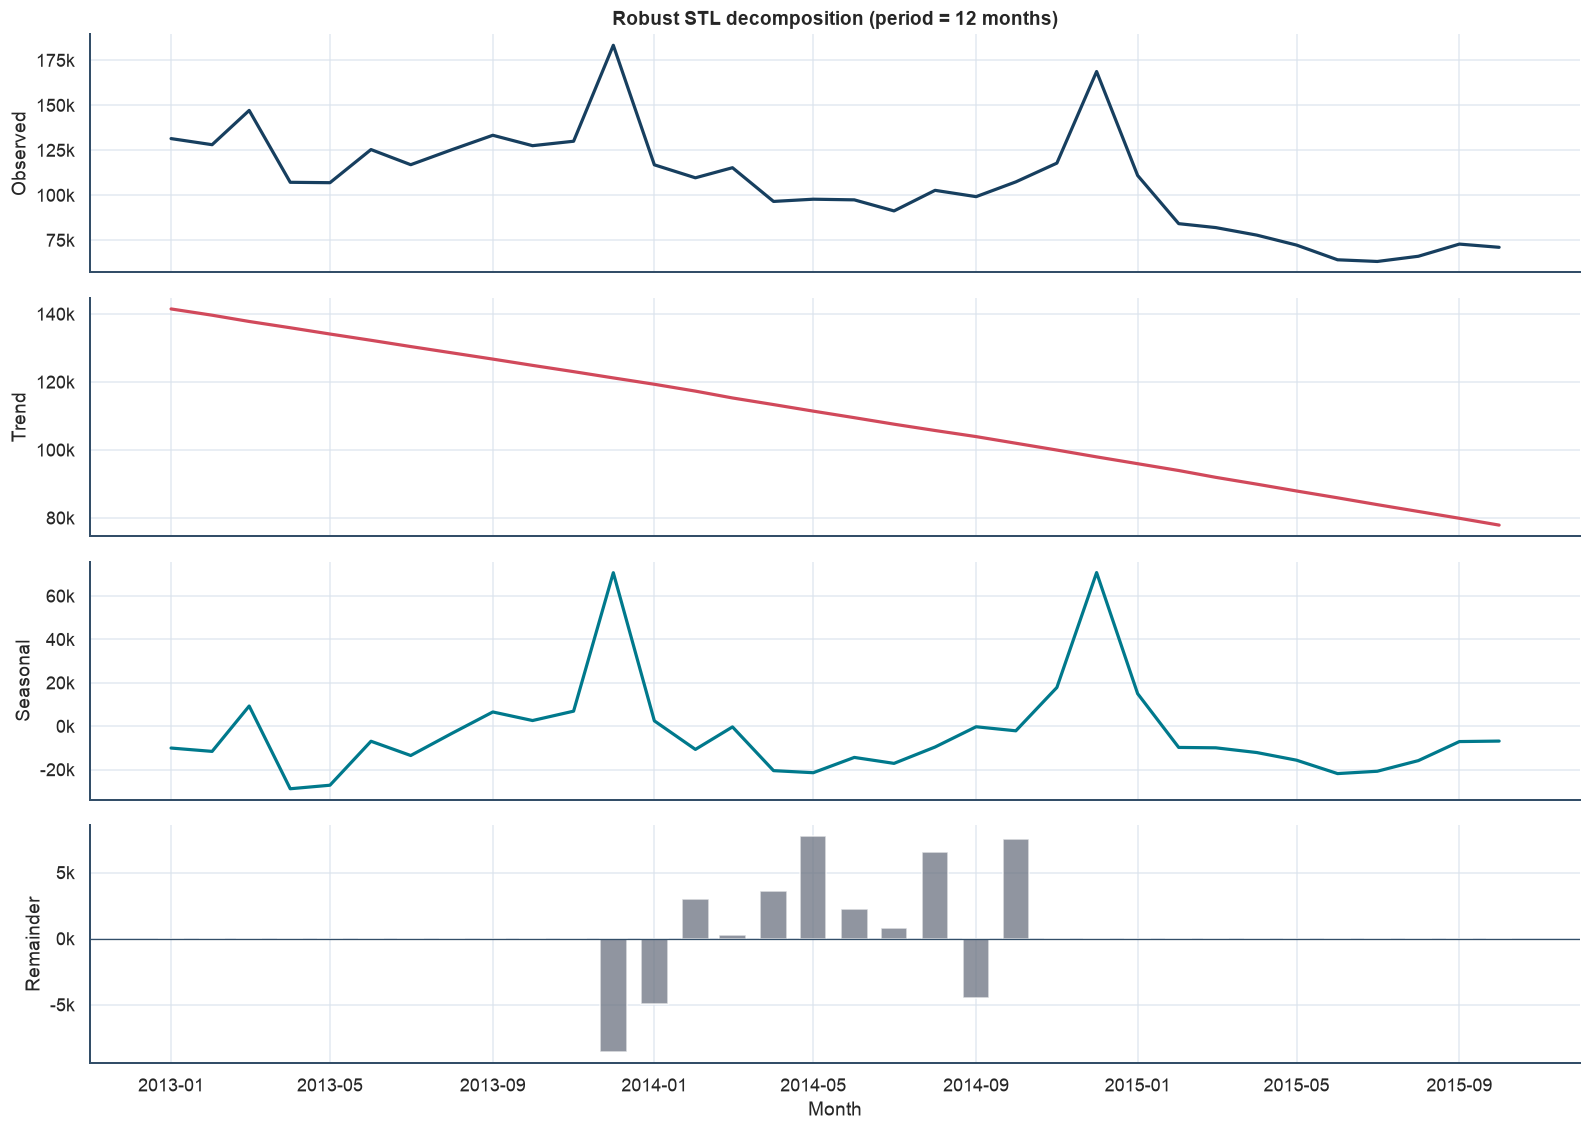

In [6]:
stl = STL(y, period=SEASON_LENGTH, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    (y, "Observed", COLORS["actual"]),
    (stl.trend, "Trend", COLORS["trend"]),
    (stl.seasonal, "Seasonal", COLORS["seasonal"]),
    (stl.resid, "Remainder", "#6B7280"),
]

for axis, (values, label, color) in zip(axes, components):
    if label == "Remainder":
        axis.axhline(0, color="#334E68", linewidth=0.8)
        axis.bar(values.index, values, width=20, color=color, alpha=0.75)
    else:
        axis.plot(values.index, values, color=color, linewidth=2)
    axis.set_ylabel(label)
    axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))
    sns.despine(ax=axis)

axes[0].set_title("Robust STL decomposition (period = 12 months)")
axes[-1].set_xlabel("Month")
fig.tight_layout()
plt.show()

### What decomposition can—and cannot—tell us

STL separates patterns descriptively. With fewer than three annual cycles, the seasonal estimate is uncertain and partly confounded with trend. Decomposition is excellent for exploration, but it does not prove that the extracted components will persist.

## 4. Stationarity and differencing

Weak stationarity means that the mean, variance, and lag covariance do not change with absolute time. ARIMA-style models are usually applied to a transformed series whose dependence is stable.

Two complementary tests are useful:

- **ADF (Augmented Dickey–Fuller):** null hypothesis = a unit root / non-stationarity.
- **KPSS (Kwiatkowski–Phillips–Schmidt–Shin):** null hypothesis = stationarity.

A small sample makes both tests uncertain, so combine tests with plots and domain knowledge.

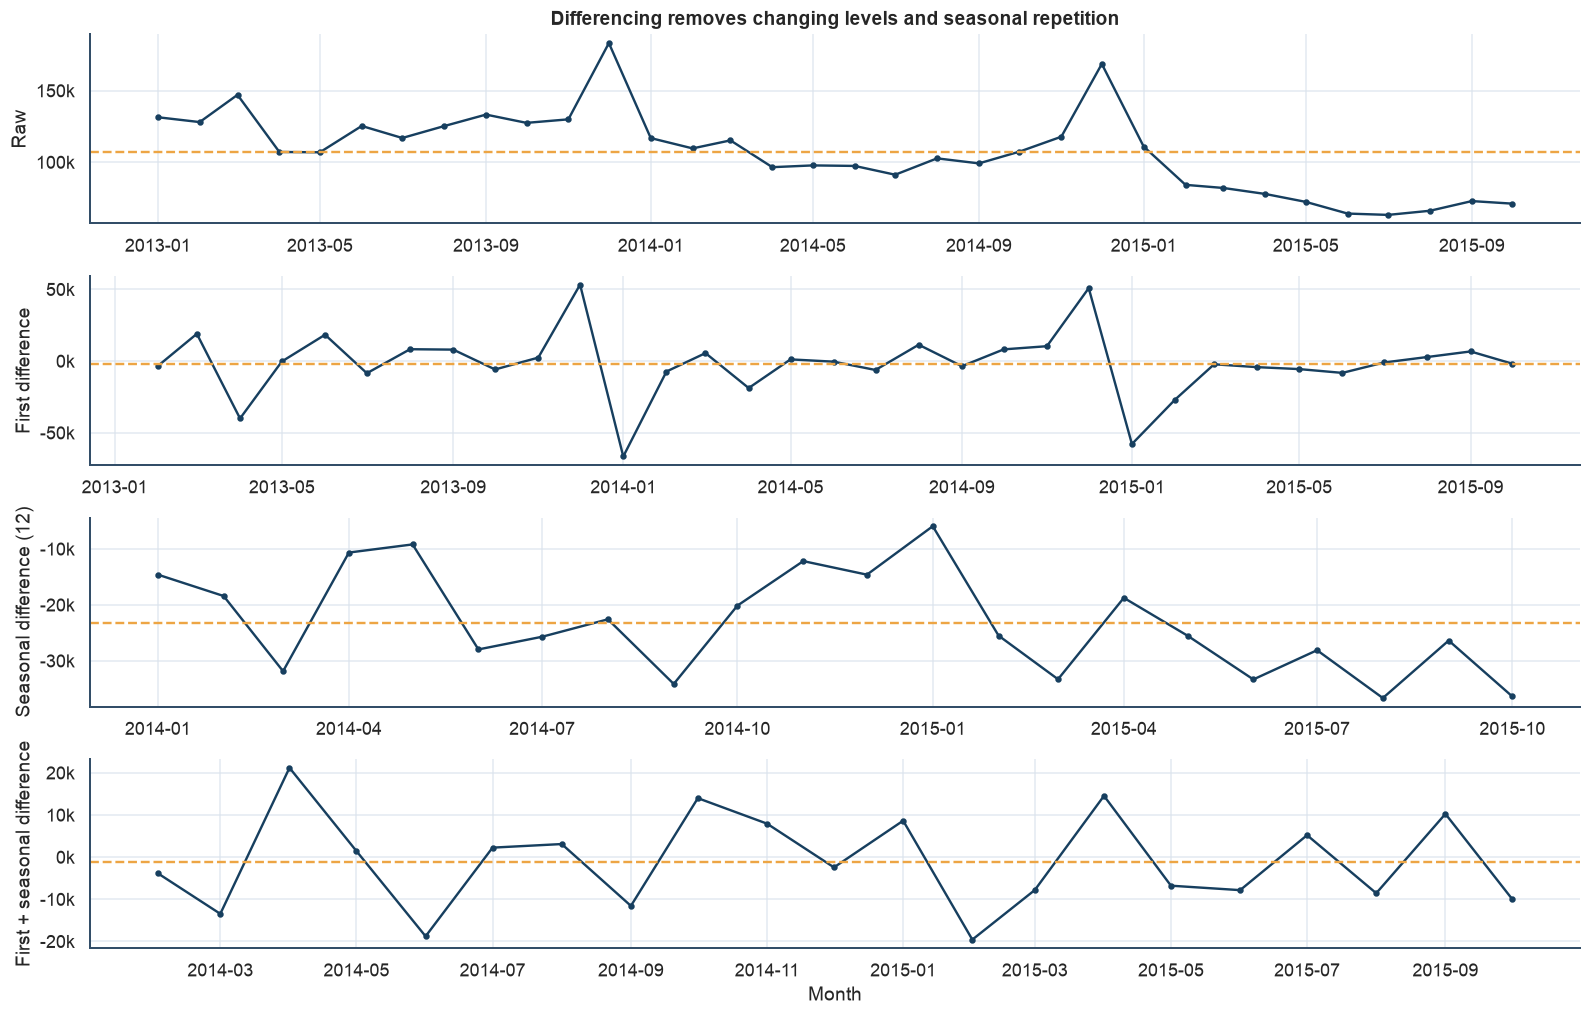

In [7]:
transformed = {
    "Raw": y,
    "First difference": y.diff().dropna(),
    "Seasonal difference (12)": y.diff(SEASON_LENGTH).dropna(),
    "First + seasonal difference": y.diff().diff(SEASON_LENGTH).dropna(),
}

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=False)
for axis, (label, series) in zip(axes, transformed.items()):
    axis.plot(series.index, series, color=COLORS["actual"], marker="o", markersize=3)
    axis.axhline(series.mean(), color=COLORS["accent"], linestyle="--", linewidth=1.5)
    axis.set_ylabel(label)
    axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))
    sns.despine(ax=axis)
axes[0].set_title("Differencing removes changing levels and seasonal repetition")
axes[-1].set_xlabel("Month")
fig.tight_layout()
plt.show()

In [8]:
def stationarity_row(label: str, series: pd.Series) -> dict:
    values = series.dropna().astype(float)
    adf_result = adfuller(values, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        kpss_result = kpss(values, regression="c", nlags="auto")
    return {
        "transformation": label,
        "n": len(values),
        "ADF statistic": adf_result[0],
        "ADF p-value": adf_result[1],
        "KPSS statistic": kpss_result[0],
        "KPSS p-value": kpss_result[1],
    }

stationarity_results = pl.DataFrame(
    [stationarity_row(label, series) for label, series in transformed.items()]
).with_columns(
    pl.col("ADF statistic", "ADF p-value", "KPSS statistic", "KPSS p-value").round(4)
)
stationarity_results

transformation,n,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
str,i64,f64,f64,f64,f64
"""Raw""",34,-2.3957,0.143,0.6283,0.0201
"""First difference""",33,-13.6362,0.0,0.3863,0.0831
"""Seasonal difference (12)""",22,-3.2701,0.0163,0.4215,0.0679
"""First + seasonal difference""",21,-6.0021,0.0,0.1798,0.1


The raw series fails the stationarity check: ADF does not reject a unit root while KPSS rejects stationarity. Differenced versions provide much stronger evidence of stationarity.

Do not difference automatically until every test passes. Over-differencing introduces unnecessary noise and can produce artificial negative autocorrelation.

## 5. ACF and PACF

For a weakly stationary series $X_t$ with autocovariance $\gamma_k$,

$$
\operatorname{ACF}(k)=\rho_k=\frac{\gamma_k}{\gamma_0}.
$$

The **Autocorrelation Function (ACF)** contains direct and intermediate-lag association. The **Partial Autocorrelation Function (PACF)** is the correlation between $X_t$ and $X_{t-k}$ after linearly removing lags $1,\ldots,k-1$.

Population heuristics:

| Process | ACF | PACF |
|---|---|---|
| AR($p$), Autoregressive | tails off | cuts off after $p$ |
| MA($q$), Moving Average | cuts off after $q$ | tails off |
| ARMA($p,q$) | tails off | tails off |

Sample plots rarely cut off perfectly. Use them to propose small candidate models—not to skip validation.

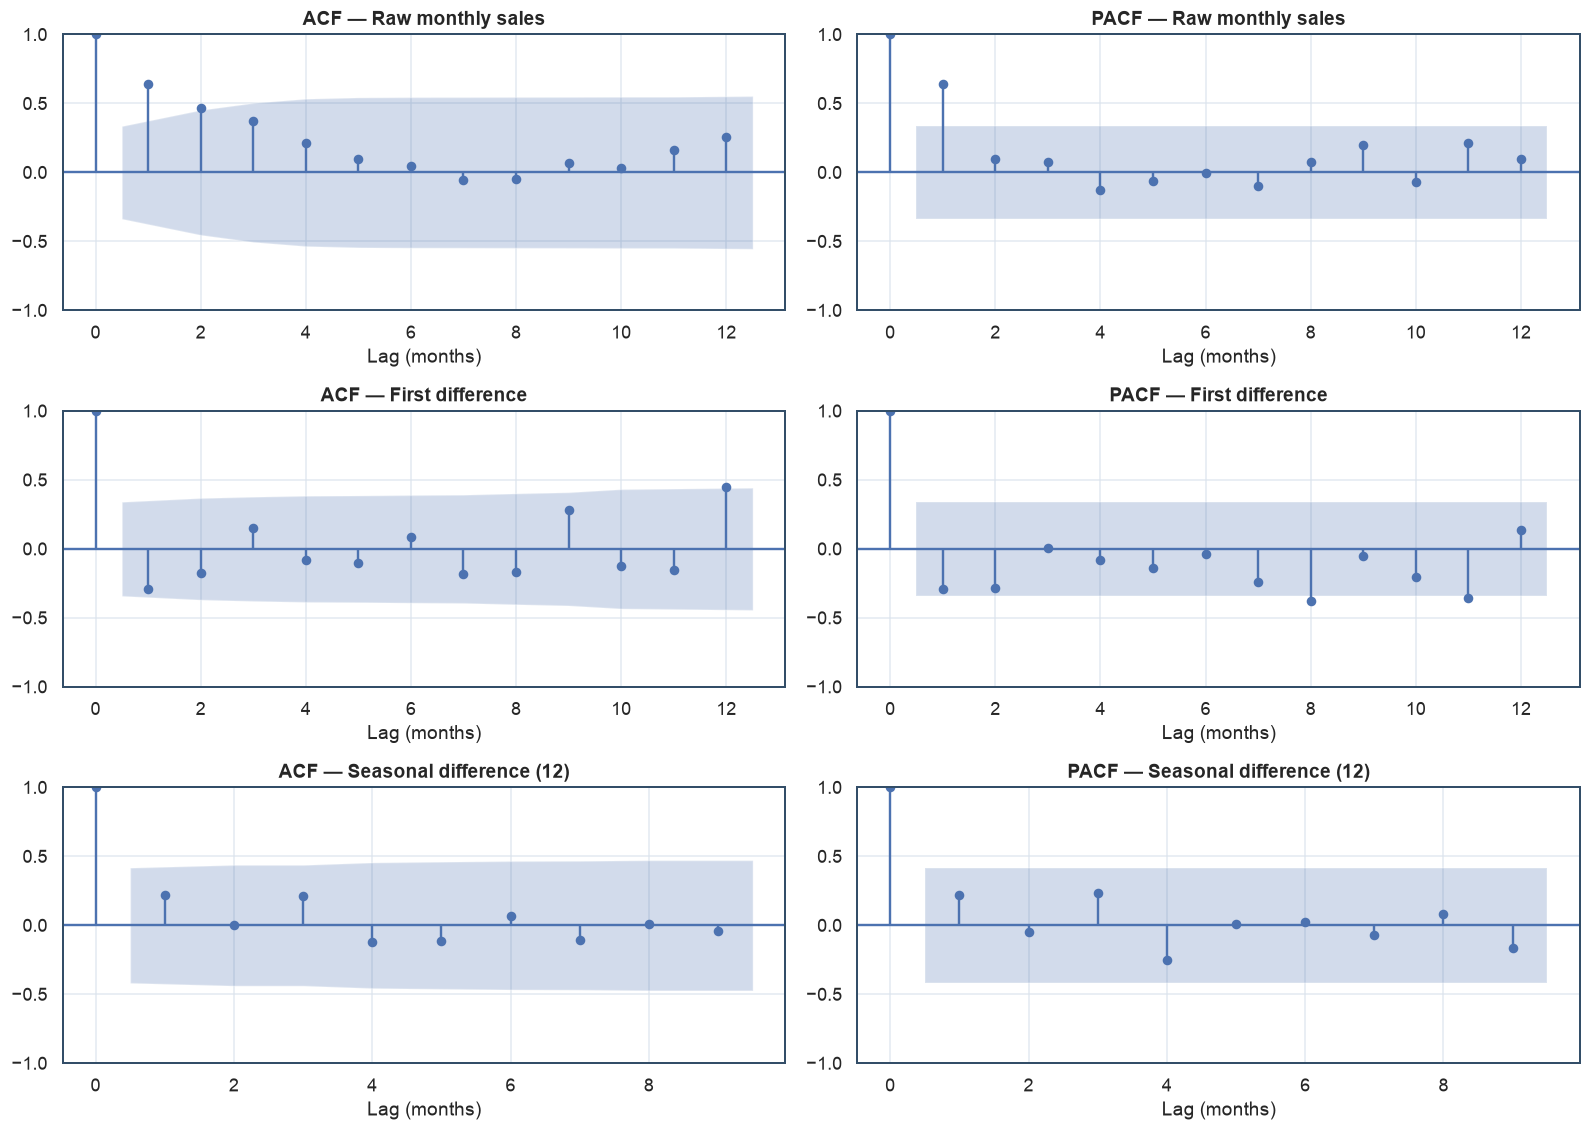

In [9]:
acf_series = [
    ("Raw monthly sales", y, 12),
    ("First difference", y.diff().dropna(), 12),
    ("Seasonal difference (12)", y.diff(12).dropna(), 9),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for row, (label, series, lags) in enumerate(acf_series):
    plot_acf(
        series,
        lags=lags,
        alpha=0.05,
        ax=axes[row, 0],
        title=f"ACF — {label}",
    )
    plot_pacf(
        series,
        lags=lags,
        alpha=0.05,
        method="ywm",
        ax=axes[row, 1],
        title=f"PACF — {label}",
    )
    axes[row, 0].set_xlabel("Lag (months)")
    axes[row, 1].set_xlabel("Lag (months)")

fig.tight_layout()
plt.show()

### Reading the plots

- Lag 0 is always 1 and is not a modeling signal.
- A spike outside the blue 95% pointwise interval is evidence of non-zero correlation, not definitive proof.
- The raw ACF mixes dependence with the falling level; transformed plots are more relevant for ARIMA orders.
- Lag 12 has a yearly interpretation for monthly data, but only two complete lag-12 pairs of years are available here.

## 6. Panel perspective: ACF/PACF by shop

Aggregation can hide heterogeneity. The next diagnostic mirrors an account-level ACF/PACF analysis: it selects four active shops reproducibly and then summarizes autocorrelation across all eligible shops.

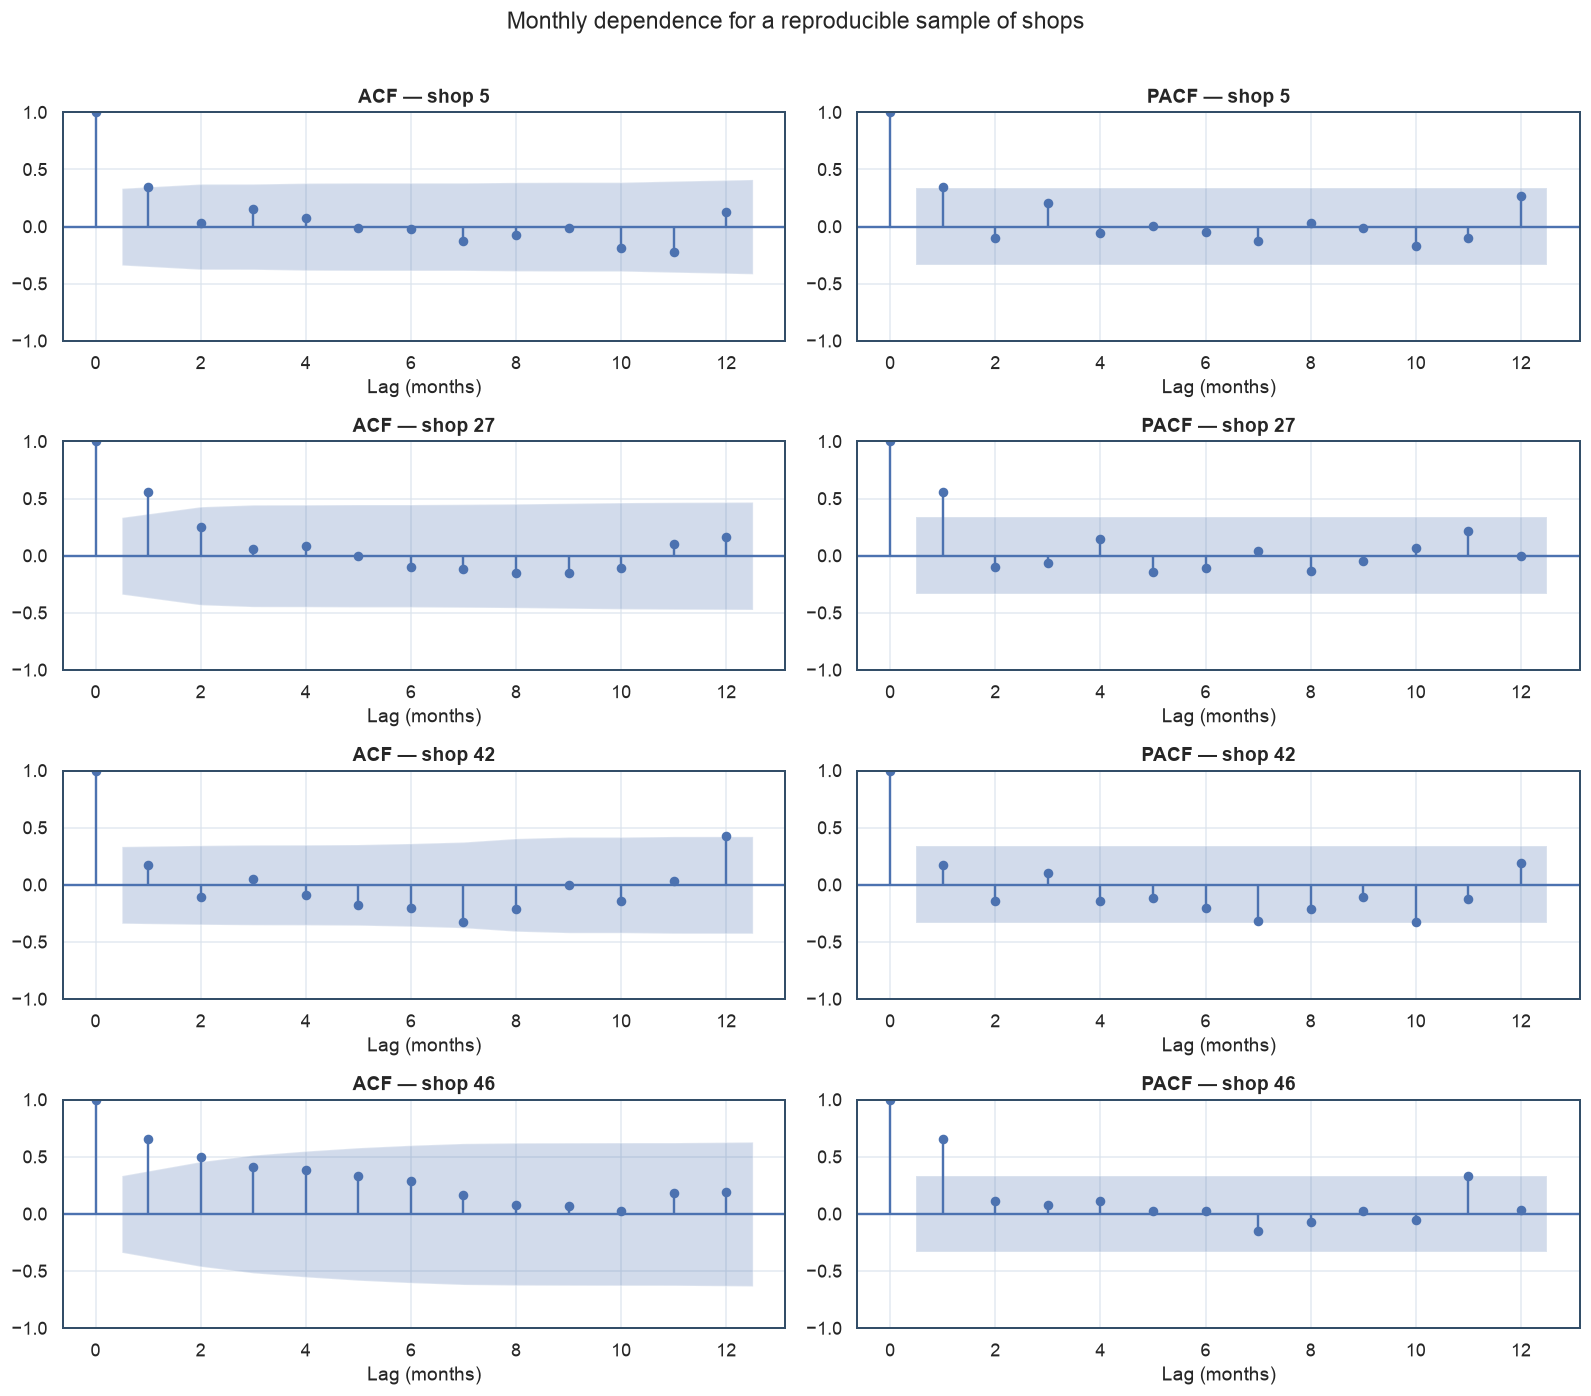

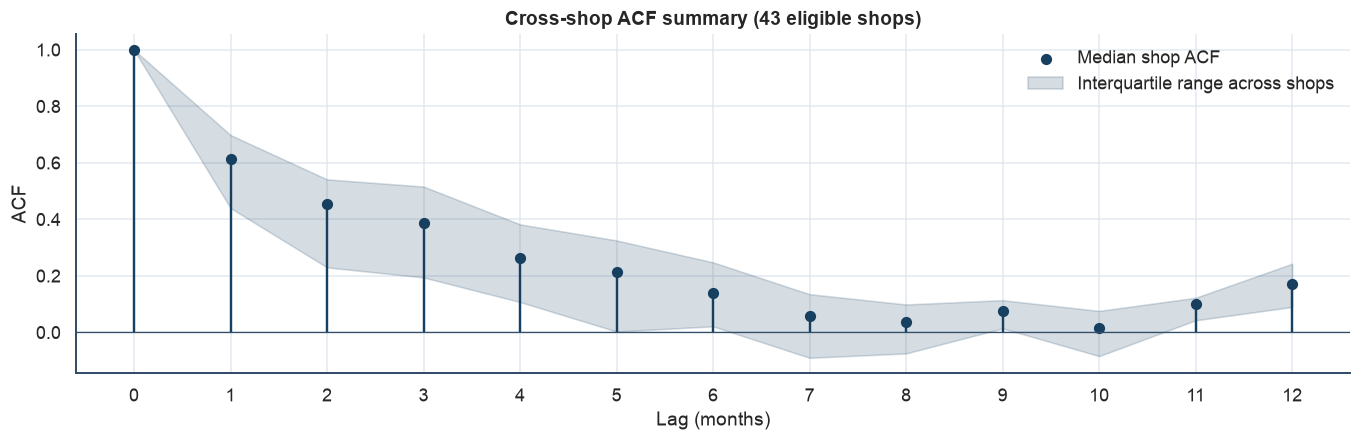

lag,mean_acf,median_acf,q25,q75,n_shops
i64,f64,f64,f64,f64,i32
1,0.572,0.616,0.44,0.699,43
6,0.139,0.141,0.022,0.248,43
12,0.18,0.17,0.09,0.243,43


In [10]:
shop_monthly = (
    sales.with_columns(pl.col("date").dt.truncate("1mo").alias("month"))
    .group_by("month", "shop_id")
    .agg(pl.col("item_cnt_day").sum().alias("net_units"))
    .sort("month", "shop_id")
)

eligible_shops = (
    shop_monthly.group_by("shop_id")
    .agg((pl.col("net_units") != 0).sum().alias("active_months"))
    .filter(pl.col("active_months") >= 24)
    .sort("shop_id")
    ["shop_id"]
    .to_numpy()
)

shop_matrix = (
    shop_monthly.pivot(on="shop_id", index="month", values="net_units")
    .sort("month")
    .fill_null(0.0)
)

selected_shops = np.sort(
    rng.choice(eligible_shops, size=min(4, len(eligible_shops)), replace=False)
)
max_shop_lags = min(12, shop_matrix.height // 2 - 1)

fig, axes = plt.subplots(
    len(selected_shops),
    2,
    figsize=(14, 3 * len(selected_shops)),
    squeeze=False,
)
for row, shop_id in enumerate(selected_shops):
    series = shop_matrix[str(shop_id)].to_numpy().astype(float)
    plot_acf(
        series,
        lags=max_shop_lags,
        alpha=0.05,
        ax=axes[row, 0],
        title=f"ACF — shop {shop_id}",
    )
    plot_pacf(
        series,
        lags=max_shop_lags,
        alpha=0.05,
        method="ywm",
        ax=axes[row, 1],
        title=f"PACF — shop {shop_id}",
    )
    axes[row, 0].set_xlabel("Lag (months)")
    axes[row, 1].set_xlabel("Lag (months)")

fig.suptitle("Monthly dependence for a reproducible sample of shops", y=1.01)
fig.tight_layout()
plt.show()

shop_acfs = np.vstack(
    [
        acf(shop_matrix[str(shop_id)].to_numpy().astype(float), nlags=max_shop_lags, fft=True)
        for shop_id in eligible_shops
    ]
)
acf_summary = pl.DataFrame(
    {
        "lag": np.arange(max_shop_lags + 1),
        "mean_acf": shop_acfs.mean(axis=0),
        "median_acf": np.median(shop_acfs, axis=0),
        "q25": np.quantile(shop_acfs, 0.25, axis=0),
        "q75": np.quantile(shop_acfs, 0.75, axis=0),
    }
)

fig, ax = plt.subplots(figsize=(12, 4))
lags = acf_summary["lag"].to_numpy()
median_acf = acf_summary["median_acf"].to_numpy()
ax.vlines(lags, 0, median_acf, color=COLORS["actual"], linewidth=1.5)
ax.scatter(lags, median_acf, color=COLORS["actual"], label="Median shop ACF")
ax.fill_between(
    lags,
    acf_summary["q25"].to_numpy(),
    acf_summary["q75"].to_numpy(),
    color=COLORS["actual"],
    alpha=0.18,
    label="Interquartile range across shops",
)
ax.axhline(0, color="#334E68", linewidth=0.8)
ax.set(
    title=f"Cross-shop ACF summary ({len(eligible_shops)} eligible shops)",
    xlabel="Lag (months)",
    ylabel="ACF",
    xticks=lags,
)
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

acf_summary.filter(pl.col("lag").is_in([1, 6, 12])).with_columns(
    pl.col("mean_acf", "median_acf", "q25", "q75").round(3),
    pl.lit(len(eligible_shops)).alias("n_shops"),
)

The shaded cross-shop region is an interquartile range, **not** a confidence interval. It shows that dependence varies materially by shop. A single aggregate model may therefore be useful for teaching but insufficient for operational shop–item forecasting.

## 7. Forecast evaluation without leakage

Random train/test splitting is invalid because it allows training on observations that occur after test observations. We use:

1. A six-month chronological holdout for visual model comparison.
2. Expanding-window, one-step backtesting for a less fragile baseline ranking.

In each split, every forecast is produced using only information available before the forecast date.

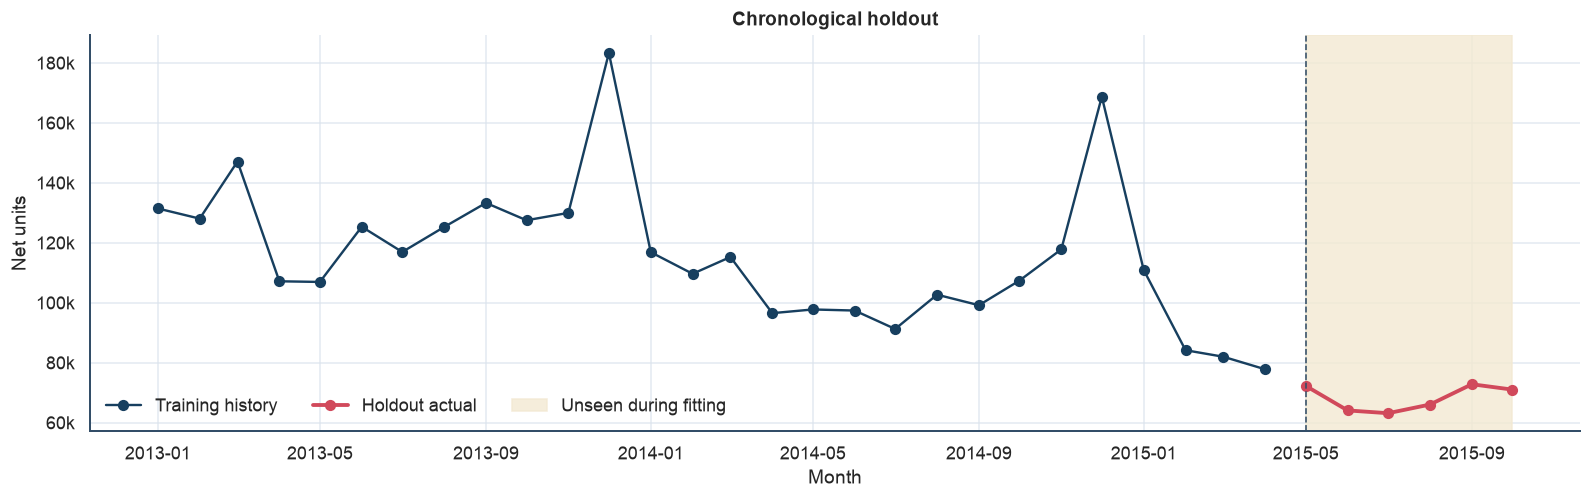

partition,first_month,last_month,observations
str,date,date,i64
"""Train""",2013-01-01,2015-04-01,28
"""Test""",2015-05-01,2015-10-01,6


In [11]:
TEST_HORIZON = 6
train = y.iloc[:-TEST_HORIZON]
test = y.iloc[-TEST_HORIZON:]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(train.index, train, color=COLORS["actual"], marker="o", label="Training history")
ax.plot(test.index, test, color=COLORS["trend"], marker="o", linewidth=2.4, label="Holdout actual")
ax.axvspan(test.index[0], test.index[-1], color=COLORS["test"], alpha=0.8, label="Unseen during fitting")
ax.axvline(test.index[0], color="#334E68", linestyle="--", linewidth=1)
ax.set(title="Chronological holdout", xlabel="Month", ylabel="Net units")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))
ax.legend(ncol=3)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

pl.DataFrame(
    {
        "partition": ["Train", "Test"],
        "first_month": [train.index.min().date(), test.index.min().date()],
        "last_month": [train.index.max().date(), test.index.max().date()],
        "observations": [len(train), len(test)],
    }
)

### Baselines first

- **Naive:** every future value equals the latest observed value.
- **Seasonal naive:** forecast the value observed 12 months earlier.
- **Drift:** connect the first and last training observations with a line and extrapolate it.

A sophisticated model should earn its complexity by beating these baselines out of sample.

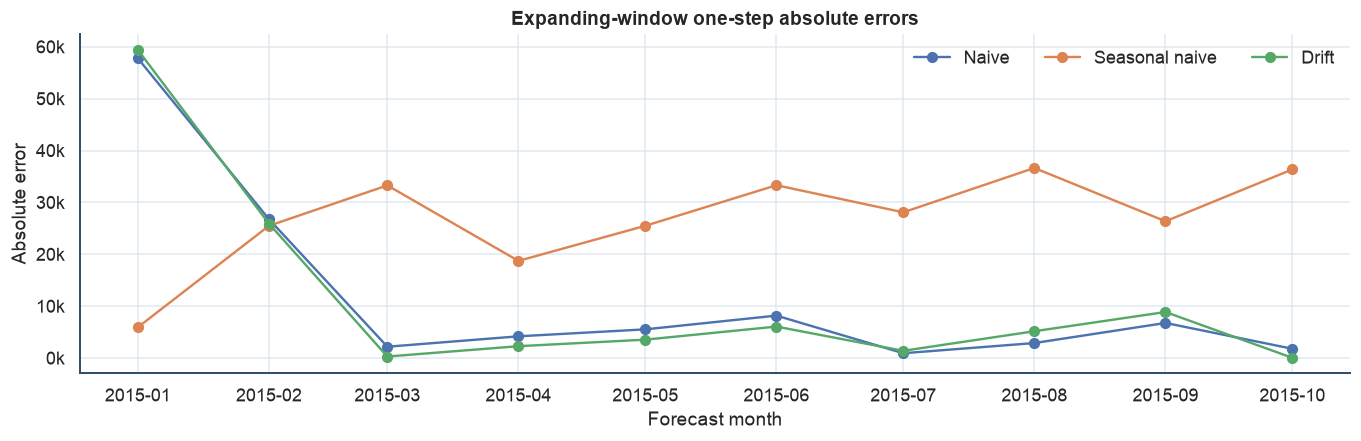

model,MAE,RMSE,forecast_origins
str,f64,f64,u32
"""Drift""",11299.6,20887.3,10
"""Naive""",11701.1,20576.2,10
"""Seasonal naive""",26970.5,28377.3,10


In [12]:
def baseline_forecasts(history: pd.Series, horizon: int, season_length: int = 12) -> dict:
    values = history.to_numpy(dtype=float)
    steps = np.arange(1, horizon + 1)
    drift_slope = (values[-1] - values[0]) / (len(values) - 1)
    return {
        "Naive": np.repeat(values[-1], horizon),
        "Seasonal naive": values[-season_length : -season_length + horizon],
        "Drift": values[-1] + drift_slope * steps,
    }

model_predictions = baseline_forecasts(train, TEST_HORIZON, SEASON_LENGTH)

def expanding_origin_baselines(series: pd.Series, initial_window: int = 24) -> pl.DataFrame:
    rows = []
    for stop in range(initial_window, len(series)):
        history = series.iloc[:stop]
        actual = float(series.iloc[stop])
        predictions = baseline_forecasts(history, horizon=1, season_length=SEASON_LENGTH)
        for model, forecast in predictions.items():
            prediction = float(forecast[0])
            rows.append(
                {
                    "forecast_month": series.index[stop].date(),
                    "model": model,
                    "actual": actual,
                    "forecast": prediction,
                    "absolute_error": abs(actual - prediction),
                }
            )
    return pl.DataFrame(rows)

rolling_results = expanding_origin_baselines(y)
rolling_metrics = (
    rolling_results.group_by("model")
    .agg(
        pl.col("absolute_error").mean().alias("MAE"),
        ((pl.col("actual") - pl.col("forecast")) ** 2).mean().sqrt().alias("RMSE"),
        pl.len().alias("forecast_origins"),
    )
    .sort("MAE")
    .with_columns(pl.col("MAE", "RMSE").round(1))
)

fig, ax = plt.subplots(figsize=(12, 4))
for model in rolling_results["model"].unique(maintain_order=True).to_list():
    model_rows = rolling_results.filter(pl.col("model") == model).sort("forecast_month")
    ax.plot(
        pd.DatetimeIndex(model_rows["forecast_month"].to_list()),
        model_rows["absolute_error"].to_numpy(),
        marker="o",
        label=model,
    )
ax.set(title="Expanding-window one-step absolute errors", xlabel="Forecast month", ylabel="Absolute error")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))
ax.legend(ncol=3)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

rolling_metrics

## 8. ETS and SARIMA models

### ETS: Error, Trend, Seasonality

Holt–Winters exponential smoothing updates level, trend, and seasonality recursively. We use additive components because seasonal swings are closer to additive units than constant percentages.

### SARIMA: Seasonal Autoregressive Integrated Moving Average

A SARIMA model is written

$$
\operatorname{SARIMA}(p,d,q)(P,D,Q)_s.
$$

Here we fit $(0,1,0)(1,0,0)_{12}$: one ordinary difference and one seasonal autoregressive term. We intentionally avoid a large order and seasonal differencing because 28 training observations cannot support many parameters.

In [13]:
ets_fit = ExponentialSmoothing(
    train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=SEASON_LENGTH,
    initialization_method="estimated",
).fit(optimized=True)
model_predictions["ETS (additive)"] = np.asarray(ets_fit.forecast(TEST_HORIZON))

sarima_spec = {
    "order": (0, 1, 0),
    "seasonal_order": (1, 0, 0, SEASON_LENGTH),
}
sarima_fit = SARIMAX(
    train,
    **sarima_spec,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarima_holdout = sarima_fit.get_forecast(steps=TEST_HORIZON)
model_predictions["SARIMA (0,1,0)(1,0,0,12)"] = sarima_holdout.predicted_mean.to_numpy()

pl.DataFrame(
    {
        "model": ["ETS (additive)", "SARIMA (0,1,0)(1,0,0,12)"],
        "parameters": [
            len(ets_fit.params),
            len(sarima_fit.params),
        ],
        "AIC": [ets_fit.aic, sarima_fit.aic],
    }
).with_columns(pl.col("AIC").round(1))

model,parameters,AIC
str,i64,f64
"""ETS (additive)""",10,534.7
"""SARIMA (0,1,0)(1,0,0,12)""",2,323.4


### Metrics

For actual values $y_t$ and forecasts $\hat y_t$:

- $\mathrm{MAE}=\operatorname{mean}|y_t-\hat y_t|$
- $\mathrm{RMSE}=\sqrt{\operatorname{mean}(y_t-\hat y_t)^2}$
- $\mathrm{sMAPE}=\operatorname{mean}\left(200|y_t-\hat y_t|/(|y_t|+|\hat y_t|)\right)$
- **MASE** divides MAE by the training error of a seasonal-naive forecast. MASE below 1 beats that scale.

No single metric is universally best. MAE is easiest to interpret here because it remains in units sold.

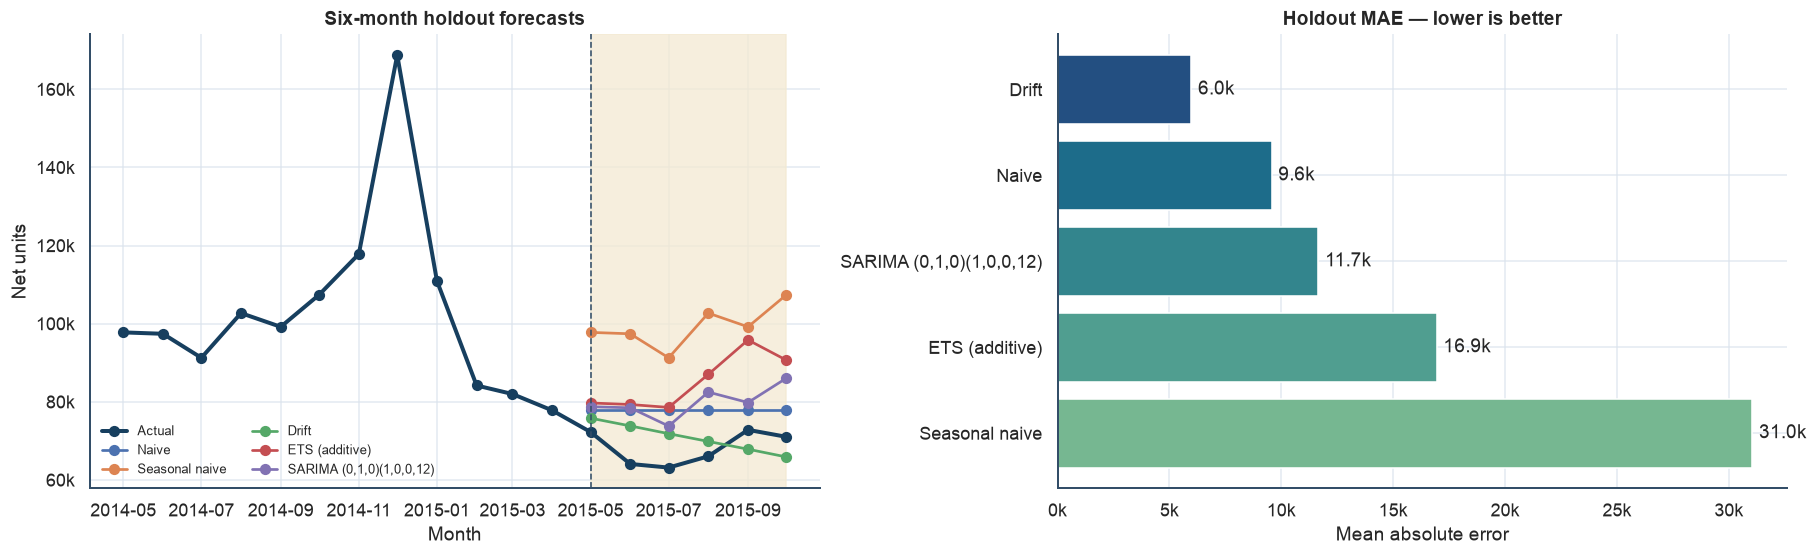

model,MAE,RMSE,sMAPE (%),MASE
str,f64,f64,f64,f64
"""Drift""",5977.5,6432.0,8.651,0.294
"""Naive""",9564.7,10341.5,13.249,0.47
"""SARIMA (0,1,0)(1,0,0,12)""",11655.2,12289.9,15.776,0.573
"""ETS (additive)""",16940.7,17691.7,21.941,0.833
"""Seasonal naive""",31046.0,31382.9,37.069,1.527


In [14]:
def forecast_metrics(
    actual: np.ndarray,
    forecast: np.ndarray,
    training: np.ndarray,
    season_length: int = 12,
) -> dict:
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    error = actual - forecast
    denominator = np.abs(actual) + np.abs(forecast)
    seasonal_scale = np.mean(
        np.abs(training[season_length:] - training[:-season_length])
    )
    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error**2)),
        "sMAPE (%)": np.mean(np.where(denominator == 0, 0, 200 * np.abs(error) / denominator)),
        "MASE": np.mean(np.abs(error)) / seasonal_scale,
    }

metric_rows = []
for model, prediction in model_predictions.items():
    metric_rows.append(
        {
            "model": model,
            **forecast_metrics(
                test.to_numpy(),
                prediction,
                train.to_numpy(),
                SEASON_LENGTH,
            ),
        }
    )

holdout_metrics = (
    pl.DataFrame(metric_rows)
    .sort("MAE")
    .with_columns(
        pl.col("MAE", "RMSE").round(1),
        pl.col("sMAPE (%)", "MASE").round(3),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(y.iloc[-18:].index, y.iloc[-18:], color=COLORS["actual"], marker="o", linewidth=2.5, label="Actual")
for model, prediction in model_predictions.items():
    axes[0].plot(test.index, prediction, marker="o", linewidth=1.7, label=model)
axes[0].axvspan(test.index[0], test.index[-1], color=COLORS["test"], alpha=0.75)
axes[0].axvline(test.index[0], color="#334E68", linestyle="--", linewidth=1)
axes[0].set(title="Six-month holdout forecasts", xlabel="Month", ylabel="Net units")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))
axes[0].legend(fontsize=8, ncol=2)
sns.despine(ax=axes[0])

metric_models = holdout_metrics["model"].to_list()[::-1]
metric_values = holdout_metrics["MAE"].to_numpy()[::-1]
axes[1].barh(metric_models, metric_values, color=sns.color_palette("crest", len(metric_models)))
for index, value in enumerate(metric_values):
    axes[1].text(value + 300, index, f"{value / 1_000:.1f}k", va="center")
axes[1].set(title="Holdout MAE — lower is better", xlabel="Mean absolute error", ylabel="")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))
sns.despine(ax=axes[1])

fig.tight_layout()
plt.show()

holdout_metrics

### Interpretation, not leaderboard worship

Drift is difficult to beat because the dominant recent pattern is decline. Seasonal naive forecasts repeat the higher 2014 level and therefore overpredict 2015. ETS and SARIMA encode useful structure but pay a variance cost with so little data.

This does **not** prove that drift is universally best. It says drift is the most defensible choice among these candidates for this dataset and evaluation window. A longer history or shop-level covariates could change the ranking.

## 9. Residual diagnostics

A model has finished extracting predictable structure only when its residuals resemble white noise:

- centered near zero,
- no visible pattern over time,
- little remaining autocorrelation,
- reasonably stable variance.

The Ljung–Box test has the null hypothesis that residual autocorrelations through the selected lag are jointly zero.

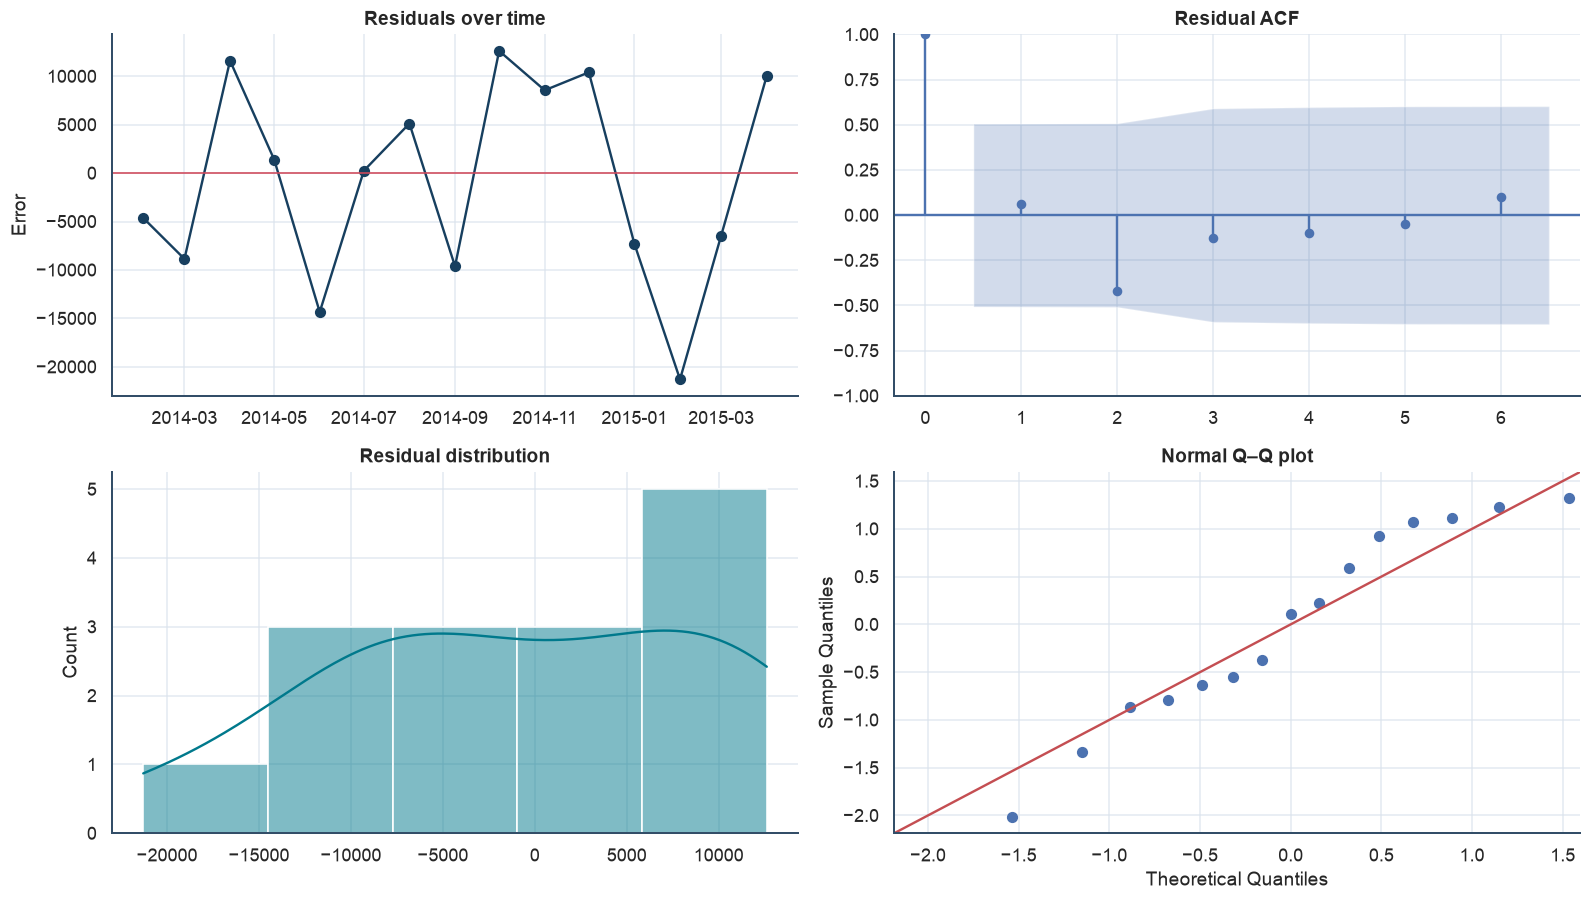

lag,Ljung-Box statistic,p-value
i64,f64,f64
4,4.1319,0.3884


In [15]:
burn = max(int(sarima_fit.loglikelihood_burn), 1)
sarima_residuals = sarima_fit.resid.iloc[burn:]
residual_lags = min(6, len(sarima_residuals) // 2 - 1)
ljung_lag = min(4, residual_lags)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(sarima_residuals.index, sarima_residuals, color=COLORS["actual"], marker="o")
axes[0, 0].axhline(0, color=COLORS["trend"], linewidth=1)
axes[0, 0].set(title="Residuals over time", ylabel="Error")

plot_acf(
    sarima_residuals,
    lags=residual_lags,
    alpha=0.05,
    ax=axes[0, 1],
    title="Residual ACF",
)
sns.histplot(sarima_residuals, kde=True, color=COLORS["seasonal"], ax=axes[1, 0])
axes[1, 0].set_title("Residual distribution")
sm.qqplot(sarima_residuals, line="45", fit=True, ax=axes[1, 1])
axes[1, 1].set_title("Normal Q–Q plot")
for axis in axes.flat:
    sns.despine(ax=axis)
fig.tight_layout()
plt.show()

ljung_box = acorr_ljungbox(
    sarima_residuals,
    lags=[ljung_lag],
    return_df=True,
)
pl.DataFrame(
    {
        "lag": ljung_box.index.to_numpy(),
        "Ljung-Box statistic": ljung_box["lb_stat"].to_numpy(),
        "p-value": ljung_box["lb_pvalue"].to_numpy(),
    }
).with_columns(pl.col("Ljung-Box statistic", "p-value").round(4))

Residual tests have low power with so few observations. A non-significant Ljung–Box result means “insufficient evidence of remaining autocorrelation,” not “the model is true.”

## 10. Refit and forecast future scenarios

Once evaluation is complete, refit using all available history. The plot compares:

- the validated drift baseline,
- the SARIMA mean forecast,
- SARIMA's 95% prediction interval.

The interval represents model-based uncertainty conditional on the model specification. It does not cover unexpected policy, assortment, store, or market changes.

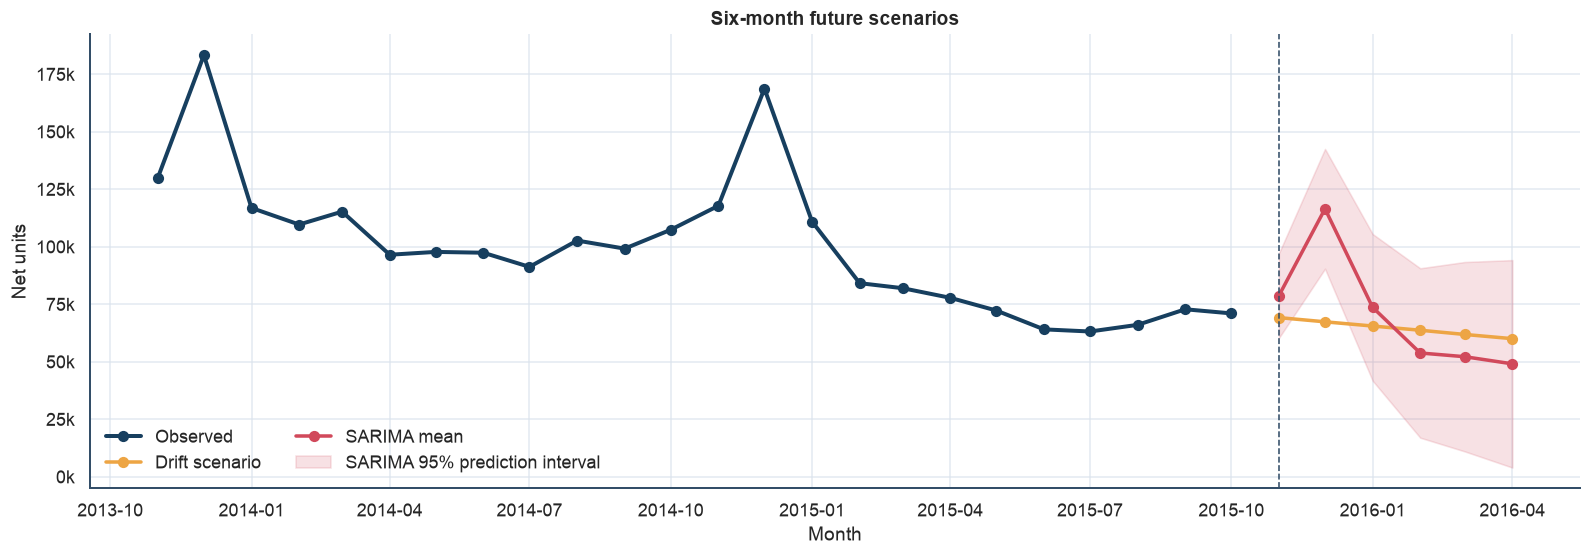

month,drift,SARIMA mean,SARIMA lower 95%,SARIMA upper 95%
object,f64,f64,f64,f64
2015-11-01,69225.0,78781.0,60370.0,97191.0
2015-12-01,67394.0,116512.0,90475.0,142548.0
2016-01-01,65563.0,73686.0,41798.0,105574.0
2016-02-01,63732.0,53844.0,17023.0,90665.0
2016-03-01,61901.0,52225.0,11058.0,93393.0
2016-04-01,60070.0,49122.0,4026.0,94219.0


In [16]:
FUTURE_HORIZON = 6
future_index = pd.date_range(
    y.index[-1] + pd.offsets.MonthBegin(1),
    periods=FUTURE_HORIZON,
    freq="MS",
)

full_drift = baseline_forecasts(y, FUTURE_HORIZON, SEASON_LENGTH)["Drift"]
full_sarima_fit = SARIMAX(
    y,
    **sarima_spec,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
full_sarima_forecast = full_sarima_fit.get_forecast(FUTURE_HORIZON)
sarima_mean = full_sarima_forecast.predicted_mean.to_numpy()
sarima_interval = full_sarima_forecast.conf_int(alpha=0.05).to_numpy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y.iloc[-24:].index, y.iloc[-24:], color=COLORS["actual"], marker="o", linewidth=2.5, label="Observed")
ax.plot(future_index, full_drift, color=COLORS["accent"], marker="o", linewidth=2.2, label="Drift scenario")
ax.plot(future_index, sarima_mean, color=COLORS["trend"], marker="o", linewidth=2.2, label="SARIMA mean")
ax.fill_between(
    future_index,
    sarima_interval[:, 0],
    sarima_interval[:, 1],
    color=COLORS["trend"],
    alpha=0.16,
    label="SARIMA 95% prediction interval",
)
ax.axvline(future_index[0], color="#334E68", linestyle="--", linewidth=1)
ax.set(title="Six-month future scenarios", xlabel="Month", ylabel="Net units")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))
ax.legend(ncol=2)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

future_forecasts = pl.DataFrame(
    {
        "month": future_index.date,
        "drift": full_drift,
        "SARIMA mean": sarima_mean,
        "SARIMA lower 95%": sarima_interval[:, 0],
        "SARIMA upper 95%": sarima_interval[:, 1],
    }
).with_columns(
    pl.col("drift", "SARIMA mean", "SARIMA lower 95%", "SARIMA upper 95%").round(0)
)
future_forecasts

The widening interval is the honest visual message: uncertainty grows with the horizon, and 34 observations cannot pin down a seasonal stochastic model precisely.

## 11. Polars lag features for machine-learning models

A time series can be converted into supervised rows. Every feature for target month $t$ must be available before $t$. Notice that the rolling mean is shifted before it is calculated; otherwise it would include the target itself and leak information.

In [17]:
lag_features = monthly_total.with_columns(
    pl.col("net_units").shift(1).alias("lag_1"),
    pl.col("net_units").shift(3).alias("lag_3"),
    pl.col("net_units").shift(12).alias("lag_12"),
    pl.col("net_units").shift(1).rolling_mean(window_size=3).alias("rolling_mean_3"),
    pl.col("net_units").shift(1).rolling_std(window_size=3).alias("rolling_std_3"),
    pl.col("month").dt.month().alias("calendar_month"),
    pl.col("month").dt.year().alias("calendar_year"),
)

lag_features.tail(15)

month,net_units,lag_1,lag_3,lag_12,rolling_mean_3,rolling_std_3,calendar_month,calendar_year
date,f64,f64,f64,f64,f64,f64,i8,i32
2014-08-01,102721.0,91280.0,97790.0,125291.0,95499.666667,3658.793563,8,2014
2014-09-01,99208.0,102721.0,97429.0,133332.0,97143.333333,5725.847041,9,2014
2014-10-01,107422.0,99208.0,91280.0,127541.0,97736.333333,5860.756976,10,2014
2014-11-01,117845.0,107422.0,102721.0,130009.0,103117.0,4121.293608,11,2014
2014-12-01,168755.0,117845.0,99208.0,183342.0,108158.333333,9340.293482,12,2014
2015-01-01,110971.0,168755.0,107422.0,116899.0,131340.666667,32818.195964,1,2015
…,…,…,…,…,…,…,…,…
2015-05-01,72295.0,77827.0,84198.0,97790.0,81346.333333,3237.552213,5,2015
2015-06-01,64114.0,72295.0,82014.0,97429.0,77378.666667,4874.986393,6,2015


These rows can feed a regularized linear model, gradient boosting, or a global model across many shop–item series. The validation logic must remain time-aware, and lag creation must occur consistently within each entity.

## 12. Practical workflow and glossary

### A defensible workflow

1. Define the target, frequency, horizon, and decision being supported.
2. Build a complete time index and decide what missing periods mean.
3. Plot the level and calendar structure before fitting anything.
4. Separate trend, seasonality, anomalies, and structural breaks conceptually.
5. Use stationarity tests and ACF/PACF as diagnostics, not commandments.
6. Establish naive, seasonal-naive, and drift baselines.
7. Backtest chronologically with the same horizon used in production.
8. Compare errors, stability, residuals, runtime, and interpretability.
9. Refit only after model selection; communicate prediction intervals and assumptions.
10. Monitor forecast errors and retrain when the data-generating process changes.

### Acronyms

- **ACF:** Autocorrelation Function
- **PACF:** Partial Autocorrelation Function
- **AR:** Autoregressive
- **MA:** Moving Average
- **ARMA:** Autoregressive Moving Average
- **ARIMA:** Autoregressive Integrated Moving Average
- **SARIMA:** Seasonal Autoregressive Integrated Moving Average
- **ETS:** Error, Trend, Seasonality
- **ADF:** Augmented Dickey–Fuller
- **KPSS:** Kwiatkowski–Phillips–Schmidt–Shin
- **AIC:** Akaike Information Criterion
- **MAE / RMSE:** Mean Absolute Error / Root Mean Squared Error
- **sMAPE / MASE:** symmetric Mean Absolute Percentage Error / Mean Absolute Scaled Error

### Suggested exercises

1. Change the holdout horizon from 6 to 3 or 12 months and compare rankings.
2. Repeat the workflow for one stable shop rather than the global total.
3. Compare additive and multiplicative ETS after a safe positive transformation.
4. Backtest several small SARIMA specifications rather than selecting by in-sample AIC alone.
5. Train a global lag-feature model across shops and compare it with per-shop baselines.

**Central lesson:** forecasting quality comes from disciplined problem framing and validation—not from choosing the most complicated model.